In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

In [55]:
iris = load_iris()

X = iris.data
y = iris.target

In [56]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (150, 4)
Shape of y : (150,)


### Exploring Dataset

In [57]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


| Key             | Description                  |
| --------------- | ---------------------------- |
| `data`          | Feature matrix (X)           |
| `target`        | Labels (y)                   |
| `feature_names` | Names of input features      |
| `target_names`  | Names of flower classes      |
| `DESCR`         | Complete dataset description |


In [58]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [59]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [60]:
print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [61]:
print(iris.target_names[y[:5]])

['setosa' 'setosa' 'setosa' 'setosa' 'setosa']


#### Visualization

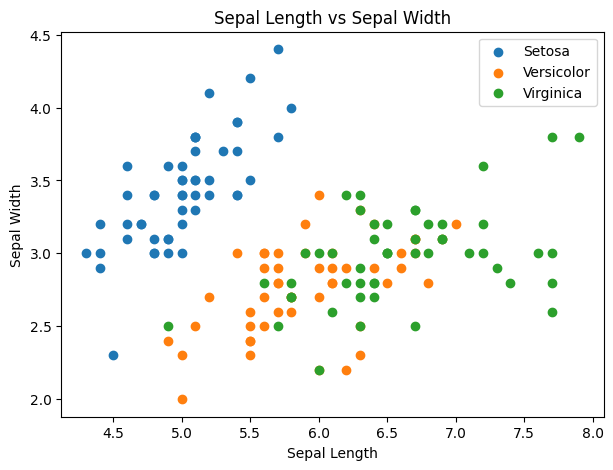

In [62]:
plt.figure(figsize=(7,5))

plt.scatter(X[y==0,0], X[y==0,1], label="Setosa")
plt.scatter(X[y==1,0], X[y==1,1], label="Versicolor")
plt.scatter(X[y==2,0], X[y==2,1], label="Virginica")

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Sepal Width")
plt.legend()

plt.show()

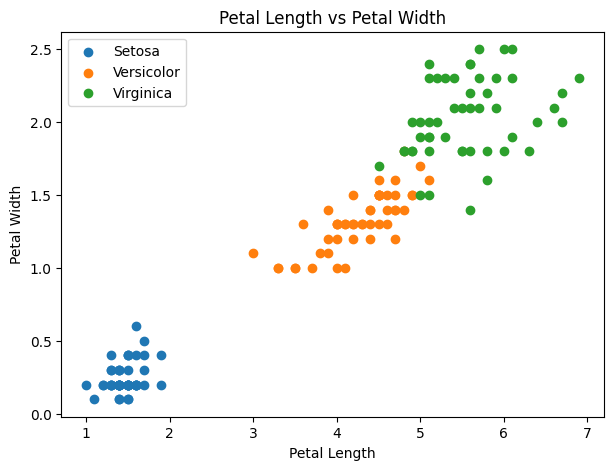

In [63]:
plt.figure(figsize=(7,5))

plt.scatter(X[y==0,2], X[y==0,3], label="Setosa")
plt.scatter(X[y==1,2], X[y==1,3], label="Versicolor")
plt.scatter(X[y==2,2], X[y==2,3], label="Virginica")

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")
plt.legend()

plt.show()

Petal features carry much more discriminative information than sepal features.

In [64]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = iris.target_names[y]

In [65]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


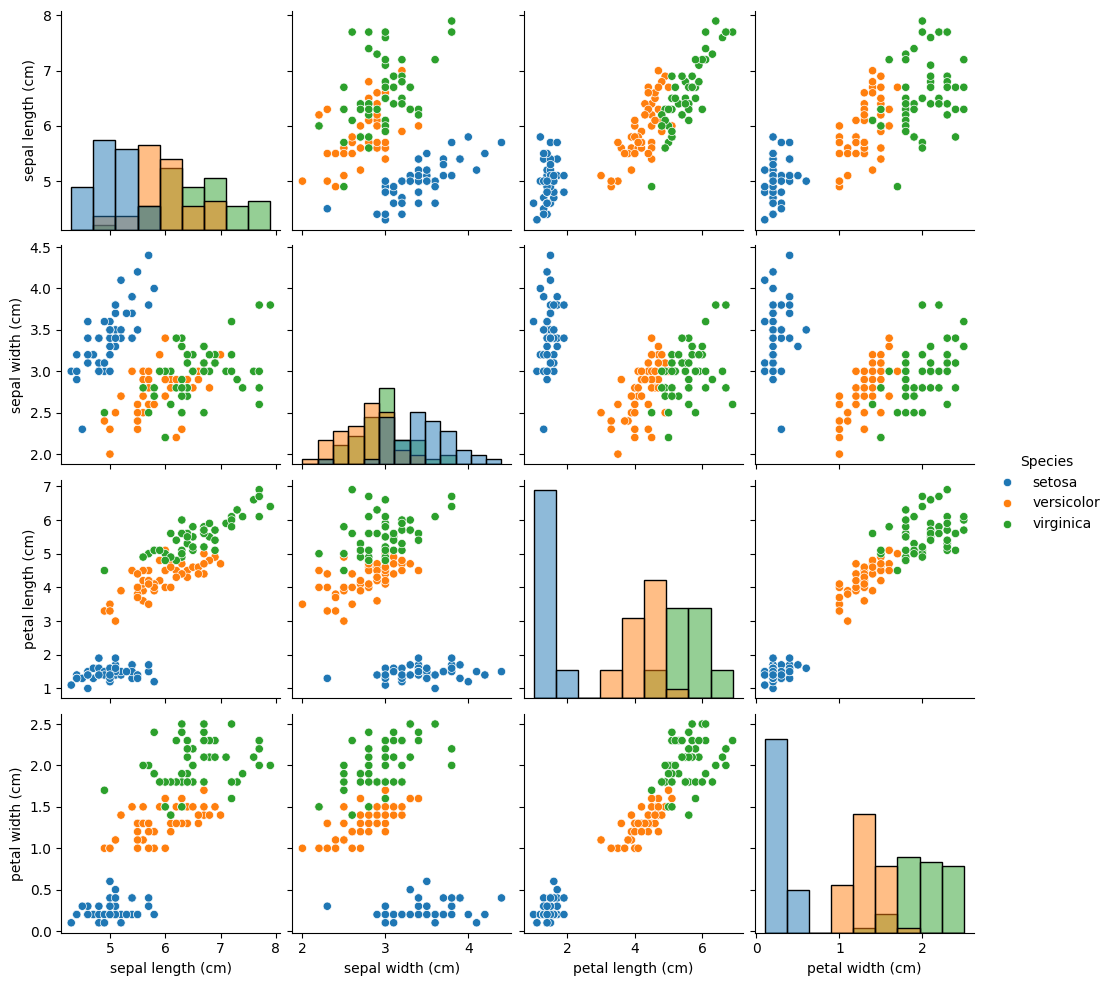

In [66]:
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.show()

### Splitting Dataset

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y

Without stratification, the split could accidentally contain more samples from one class than another.

With it, the class proportions are preserved.

In [69]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (120, 4)
X_test : (30, 4)
y_train: (120,)
y_test : (30,)


### Normalization

In [70]:
mean = np.mean(X_train, axis=0)
print(mean)

[5.84166667 3.04833333 3.77       1.205     ]


In [71]:
std = np.std(X_train, axis=0)

print(std)

[0.837415   0.44665112 1.761136   0.75947899]


In [72]:
X_train_std = (X_train - mean) / std

Do NOT compute a new mean or std.

In [73]:
X_test_std = (X_test - mean) / std

In [74]:
print(np.mean(X_train_std, axis=0))

[-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]


In [75]:
print(np.std(X_train_std, axis=0))

[1. 1. 1. 1.]


#### One-Hot Encode the Labels

👉👉👉 https://chatgpt.com/s/t_6a4295b158f081919a2f97e63851d6b3

In [76]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [77]:
num_classes = len(np.unique(y_train))

print(num_classes)

3


In [78]:
y_train_onehot = np.zeros((len(y_train), num_classes))
y_train_onehot[:5]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [79]:
print(y_train_onehot.shape)

(120, 3)


In [80]:
np.arange(len(y_train))

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119])

In [81]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [82]:
y_train_onehot[:5]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [83]:
y_train_onehot[np.arange(len(y_train)), y_train] = 1

In [84]:
print(y_train_onehot[:5])

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [85]:
y_test_onehot = np.zeros((len(y_test), num_classes))
y_test_onehot[np.arange(len(y_test)), y_test] = 1

### Implementing Softmax Function

| Mathematical Formula               | NumPy Code              |
| ---------------------------------- | ----------------------- |
| (e^{z_i})                          | `np.exp(z)`             |
| (\sum_j e^{z_j})                   | `np.sum(exp_z)`         |
| (\frac{e^{z_i}}{\sum_j e^{z_j}})   | `exp_z / np.sum(exp_z)` |
| *(No equivalent; numerical trick)* | `z = z - np.max(z)`     |


In [86]:
def softmax(z):
    """
    z = [2.5, 1.2, 0.3]

         z₁   z₂   z₃
    -------
    numpy.ndarray
        Softmax probabilities with the same shape as z.
    """
    # Numerical stability
    z = z - np.max(z, axis=-1, keepdims=True)

    # Exponentiate
    exp_z = np.exp(z)

    # Normalize
    probabilities = exp_z / np.sum(exp_z, axis=-1, keepdims=True)

    return probabilities

axis=-1 targets the last dimension of an array

keepdims=True forces the operation to retain that dimension with a size of 1

In [87]:
logits = np.array([2.5, 1.2, 0.3])

probabilities = softmax(logits)

print("Logits:")
print(logits)

print("\nSoftmax Probabilities:")
print(probabilities)

print("\nSum of probabilities:")
print(probabilities.sum())

Logits:
[2.5 1.2 0.3]

Softmax Probabilities:
[0.72289072 0.1970107  0.08009858]

Sum of probabilities:
1.0


### Cross Entropy Loss

In [88]:
def cross_entropy_loss(y_true, y_pred):

    # Prevent log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Compute loss
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    return loss

#### Initialize Wights & Bias

In [89]:
num_features = X_train_std.shape[1]
print(num_features)

4


In [90]:
num_classes = y_train_onehot.shape[1]
print(num_classes)

3


In [91]:
W = np.zeros((num_features, num_classes))
W

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [92]:
b = np.zeros((1, num_classes))
b

array([[0., 0., 0.]])

In [93]:
logits = X_train_std @ W + b
probabilities = softmax(logits)

In [94]:
print(probabilities[:5])

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


### Gradients

In [95]:
def compute_gradients(X, y_true, y_pred):

    m = X.shape[0]

    dW = (1 / m) * (X.T @ (y_pred - y_true))
    db = (1 / m) * np.sum(y_pred - y_true,
                          axis=0,
                          keepdims=True)

    return dW, db

In [96]:
learning_rate = 0.1
epochs = 1000

loss_history = []
sample_index = 0

prob_history = []

for epoch in range(epochs):

    # Forward propagation
    logits = X_train_std @ W + b
    probabilities = softmax(logits)
    prob_history.append(probabilities[sample_index])

    # Compute loss
    loss = cross_entropy_loss(
        y_train_onehot,
        probabilities
    )

    loss_history.append(loss)

    # Compute gradients
    dW, db = compute_gradients(
        X_train_std,
        y_train_onehot,
        probabilities
    )

    # Update parameters
    W -= learning_rate * dW
    b -= learning_rate * db

    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss:.4f}")

Epoch    0 | Loss = 1.0986
Epoch  100 | Loss = 0.3204
Epoch  200 | Loss = 0.2519
Epoch  300 | Loss = 0.2121
Epoch  400 | Loss = 0.1852
Epoch  500 | Loss = 0.1659
Epoch  600 | Loss = 0.1514
Epoch  700 | Loss = 0.1400
Epoch  800 | Loss = 0.1309
Epoch  900 | Loss = 0.1234


In [97]:
def predict(X, W, b):

    logits = X @ W + b

    probabilities = softmax(logits)

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return predictions

In [98]:
y_pred = predict(
    X_test_std,
    W,
    b
)

print(y_pred[:10])

[0 2 1 1 0 1 0 0 2 1]


In [99]:
accuracy = np.mean(
    y_pred == y_test
)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 93.33%


In [100]:
for i in range(10):
    print(
        f"Actual: {y_test[i]}   Predicted: {y_pred[i]}"
    )

Actual: 0   Predicted: 0
Actual: 2   Predicted: 2
Actual: 1   Predicted: 1
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 1   Predicted: 1
Actual: 0   Predicted: 0
Actual: 0   Predicted: 0
Actual: 2   Predicted: 2
Actual: 1   Predicted: 1


### Using Scikit Learn

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# Train
model.fit(X_train_std, y_train)

# Predict
y_pred = model.predict(X_test_std)

# Predict probabilities
y_prob = model.predict_proba(X_test_std)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nFirst 5 Predictions:")
print(y_pred[:5])

print("\nFirst 5 Probability Vectors:")
print(y_prob[:5])

Accuracy: 0.9333333333333333

First 5 Predictions:
[0 2 1 1 0]

First 5 Probability Vectors:
[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]
 [1.48799040e-01 8.42474895e-01 8.72606441e-03]
 [9.54449962e-02 8.94618634e-01 9.93636953e-03]
 [9.88493051e-01 1.15067767e-02 1.72549650e-07]]


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


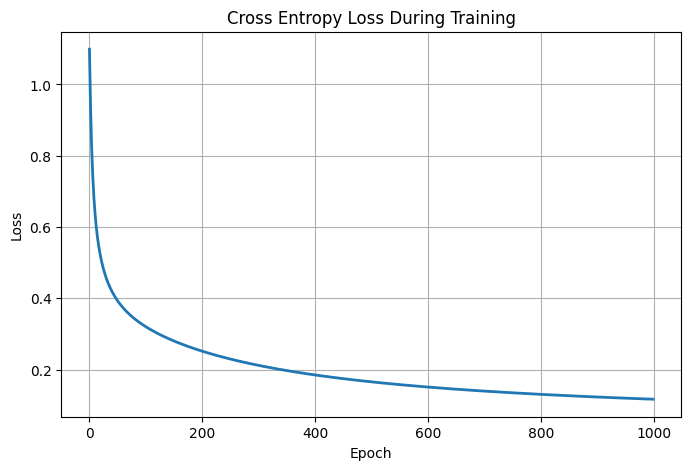

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)

plt.title("Cross Entropy Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

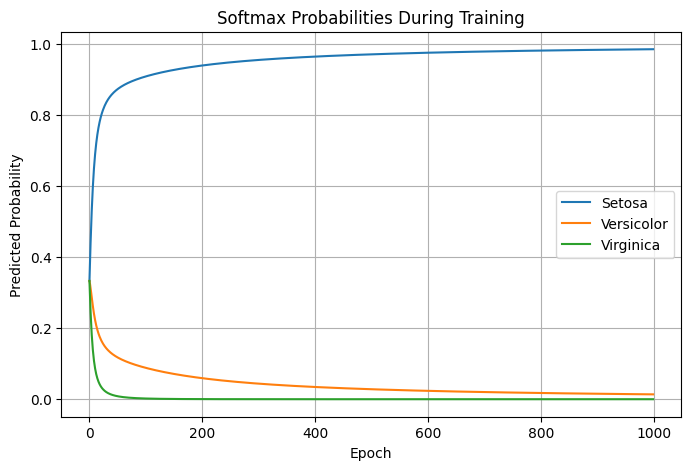

In [103]:
prob_history = np.array(prob_history)

plt.figure(figsize=(8,5))

plt.plot(prob_history[:,0], label="Setosa")
plt.plot(prob_history[:,1], label="Versicolor")
plt.plot(prob_history[:,2], label="Virginica")

plt.xlabel("Epoch")
plt.ylabel("Predicted Probability")
plt.title("Softmax Probabilities During Training")

plt.legend()
plt.grid(True)

plt.show()

During training, the model became more and more confident that this sample belongs to Setosa.

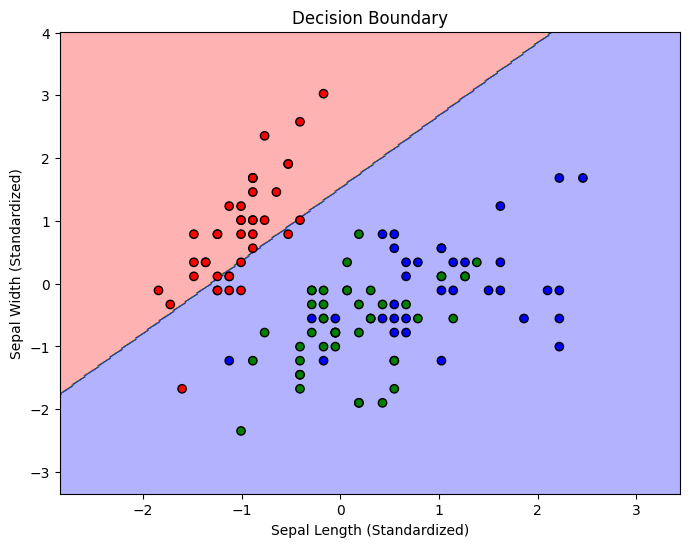

In [104]:
from matplotlib.colors import ListedColormap

X_vis = X_train_std[:, :2]

W_vis = W[:2]
h = 0.02

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

logits = grid @ W_vis + b
Z = np.argmax(softmax(logits), axis=1)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z,
             alpha=0.3,
             cmap=ListedColormap(["red","green","blue"]))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_train,
    cmap=ListedColormap(["red","green","blue"]),
    edgecolor="k"
)

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("Decision Boundary")

plt.show()

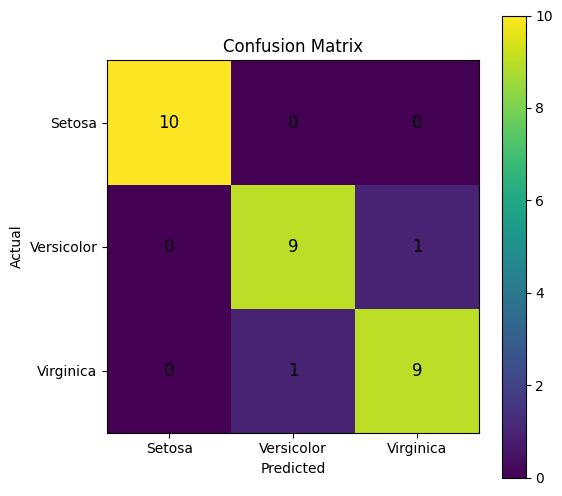

In [105]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1,2],
           ["Setosa","Versicolor","Virginica"])

plt.yticks([0,1,2],
           ["Setosa","Versicolor","Virginica"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

                 Predicted
             Setosa  Versicolor  Virginica

(Real)Setosa

(R)Versicolor

(R)Virginica

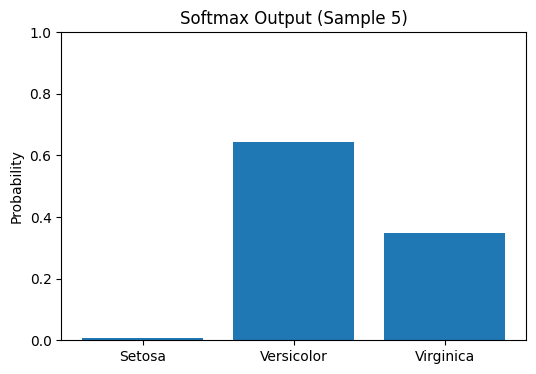

Actual : 1
Predicted : 1


In [106]:
sample = 5

probs = softmax(
    X_test_std[sample].reshape(1,-1) @ W + b
).flatten()
classes = ["Setosa","Versicolor","Virginica"]

plt.figure(figsize=(6,4))

plt.bar(classes, probs)

plt.ylim(0,1)

plt.ylabel("Probability")

plt.title(f"Softmax Output (Sample {sample})")

plt.show()

print("Actual :", y_test[sample])
print("Predicted :", y_pred[sample])

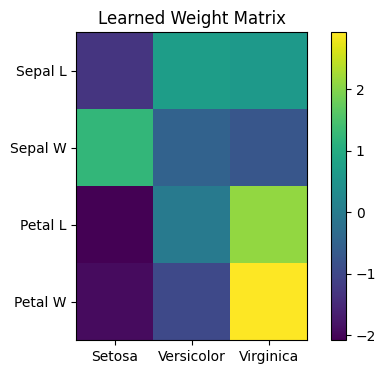

In [107]:
plt.figure(figsize=(6,4))

plt.imshow(W)

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["Setosa","Versicolor","Virginica"]
)

plt.yticks(
    [0,1,2,3],
    ["Sepal L","Sepal W","Petal L","Petal W"]
)

plt.title("Learned Weight Matrix")

plt.show()

In [108]:
for i in range(10):

    probs = softmax(
        X_test_std[i].reshape(1,-1) @ W + b
    ).flatten()

    print(f"Sample {i}")
    print(f"Actual    : {y_test[i]}")
    print(f"Predicted : {y_pred[i]}")
    print(f"Probabilities : {probs}")
    print("-"*50)

Sample 0
Actual    : 0
Predicted : 0
Probabilities : [9.91699242e-01 8.30068333e-03 7.49606099e-08]
--------------------------------------------------
Sample 1
Actual    : 2
Predicted : 2
Probabilities : [0.00119331 0.30125361 0.69755308]
--------------------------------------------------
Sample 2
Actual    : 1
Predicted : 1
Probabilities : [0.1077536  0.88488596 0.00736044]
--------------------------------------------------
Sample 3
Actual    : 1
Predicted : 1
Probabilities : [0.06034482 0.93156025 0.00809493]
--------------------------------------------------
Sample 4
Actual    : 0
Predicted : 0
Probabilities : [9.96179202e-01 3.82076656e-03 3.10036000e-08]
--------------------------------------------------
Sample 5
Actual    : 1
Predicted : 1
Probabilities : [0.00824264 0.64349763 0.34825973]
--------------------------------------------------
Sample 6
Actual    : 0
Predicted : 0
Probabilities : [9.99082531e-01 9.17464463e-04 4.09291423e-09]
------------------------------------------